In [ ]:
import pandas as pd #importing pandas library for dataset manipulation

df=pd.read_csv('Dataset/data.csv') #loading the dataset
# print(df.head()) #printing the first 5 rows of dataset


#print("Columns in the Dataset") 
#print(df.columns) #prints the columns present in the dataset
    
print("\nSentiment distribution:")
df['Sentiment'].value_counts() #Lists the no of entries for specific sentiment values





Sentiment distribution:


Sentiment
neutral     3130
positive    1852
negative     860
Name: count, dtype: int64

In [2]:
import re

# Clean text function
def clean_text(text):
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)  # Remove URLs
    text = re.sub(r'\@\w+|\#', '', text)                # Remove mentions/hashtags
    text = re.sub(r'[^\w\s]', '', text)                 # Remove punctuation
    text = re.sub(r'\d+', '', text)                     # Remove numbers
    text = text.lower().strip()                         # Convert to lowercase
    return text

# Apply to 'Sentence' column
df['clean_text'] = df['Sentence'].apply(clean_text)

# Preview cleaned text
df[['Sentence', 'clean_text']].head()



,Sentence,clean_text
0,The GeoSolutions technology will leverage Bene...,the geosolutions technology will leverage bene...
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",esi on lows down to bk a real possibility
2,"For the last quarter of 2010 , Componenta 's n...",for the last quarter of componenta s net sal...
3,According to the Finnish-Russian Chamber of Co...,according to the finnishrussian chamber of com...
4,The Swedish buyout firm has sold its remaining...,the swedish buyout firm has sold its remaining...


In [3]:
from sklearn.preprocessing import LabelEncoder

#Encode the Sentiment column
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['Sentiment'])

#Preview encoded labels
df[['Sentiment', 'label']].head()
df.head()


,Sentence,Sentiment,clean_text,label
0,The GeoSolutions technology will leverage Bene...,positive,the geosolutions technology will leverage bene...,2
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,esi on lows down to bk a real possibility,0
2,"For the last quarter of 2010 , Componenta 's n...",positive,for the last quarter of componenta s net sal...,2
3,According to the Finnish-Russian Chamber of Co...,neutral,according to the finnishrussian chamber of com...,1
4,The Swedish buyout firm has sold its remaining...,neutral,the swedish buyout firm has sold its remaining...,1


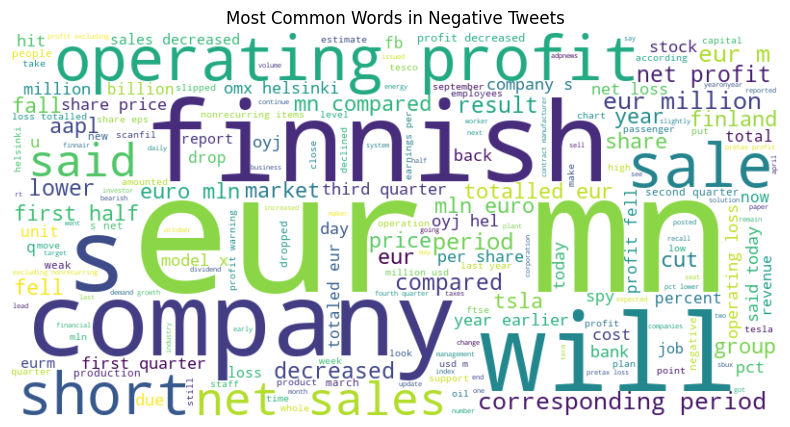

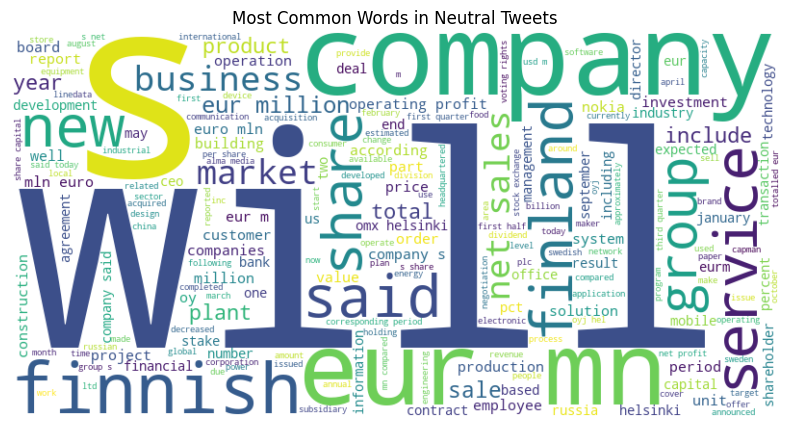

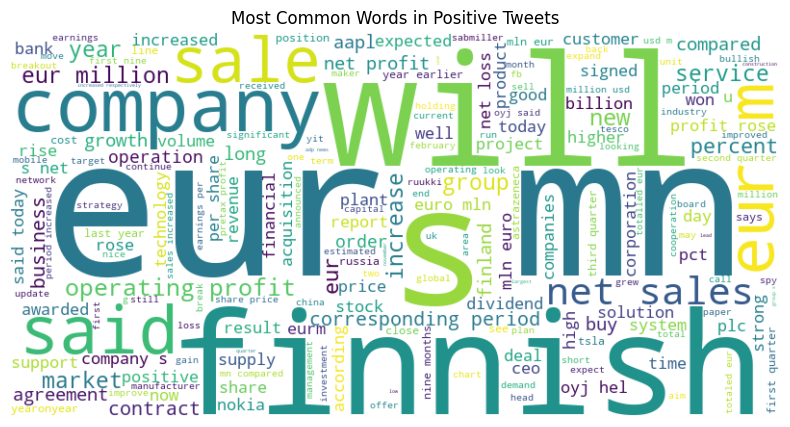

In [4]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Group tweets by sentiment
sentiments = label_encoder.classes_

for sentiment in sentiments:
    text = " ".join(df[df['Sentiment'] == sentiment]['clean_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Most Common Words in {sentiment.capitalize()} Tweets")
    plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_7920\1855171811.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', palette='pastel')


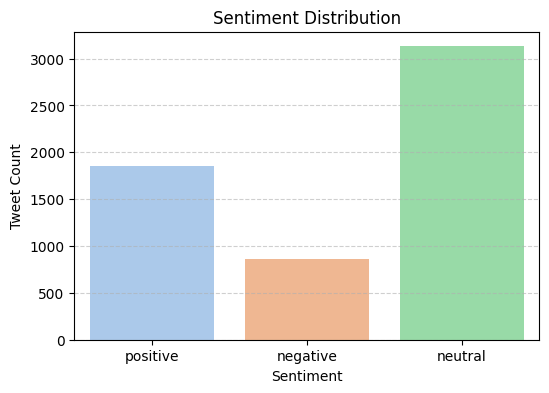

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot sentiment class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Sentiment', palette='pastel')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Tweet Count")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()



In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

#Create TF-IDF features from cleaned text
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_text'])

#Target labels
y = df['label']

#Check shape
print(f"TF-IDF shape: {X_tfidf.shape}")




TF-IDF shape: (5842, 5000)


In [7]:
from sklearn.model_selection import train_test_split

#Split into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)



In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

from sklearn.metrics import classification_report, accuracy_score

# Predict on validation set
y_pred = model.predict(X_valid)

# Results
print("Accuracy:", accuracy_score(y_valid, y_pred))
print("\nClassification Report:")
print(classification_report(y_valid, y_pred, target_names=label_encoder.classes_))




Accuracy: 0.7254063301967494

Classification Report:
              precision    recall  f1-score   support

    negative       0.52      0.15      0.24       175
     neutral       0.72      0.90      0.80       622
    positive       0.78      0.70      0.74       372

    accuracy                           0.73      1169
   macro avg       0.67      0.58      0.59      1169
weighted avg       0.71      0.73      0.69      1169



In [9]:
from sklearn.svm import LinearSVC

# Initialize and train SVM
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_svm = svm_model.predict(X_valid)

print("🔍 SVM Accuracy:", accuracy_score(y_valid, y_pred_svm))
print("\n📋 Classification Report:")
print(classification_report(y_valid, y_pred_svm, target_names=label_encoder.classes_))



🔍 SVM Accuracy: 0.7074422583404619

📋 Classification Report:
              precision    recall  f1-score   support

    negative       0.36      0.25      0.30       175
     neutral       0.73      0.82      0.77       622
    positive       0.79      0.74      0.76       372

    accuracy                           0.71      1169
   macro avg       0.63      0.60      0.61      1169
weighted avg       0.69      0.71      0.70      1169



In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_valid)

print("🔍 Random Forest Accuracy:", accuracy_score(y_valid, y_pred_rf))
print("\n📋 Classification Report:")
print(classification_report(y_valid, y_pred_rf, target_names=label_encoder.classes_))





🔍 Random Forest Accuracy: 0.6544054747647562

📋 Classification Report:
              precision    recall  f1-score   support

    negative       0.22      0.13      0.16       175
     neutral       0.66      0.84      0.74       622
    positive       0.81      0.59      0.68       372

    accuracy                           0.65      1169
   macro avg       0.56      0.52      0.53      1169
weighted avg       0.64      0.65      0.63      1169



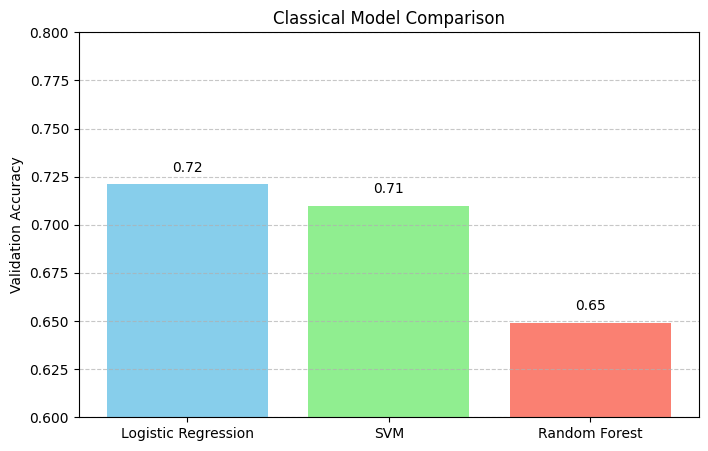

In [11]:
# Replace these with your actual results
accuracies = {
    "Logistic Regression": 0.721,  # Replace with actual
    "SVM": 0.710,                  # Replace with actual
    "Random Forest": 0.649         # Replace with actual
}

import matplotlib.pyplot as plt

# Extract labels and values
models = list(accuracies.keys())
scores = list(accuracies.values())

# Plotting
plt.figure(figsize=(8, 5))
bars = plt.bar(models, scores, color=['skyblue', 'lightgreen', 'salmon'])
plt.ylim(0.6, 0.8)
plt.ylabel("Validation Accuracy")
plt.title("Classical Model Comparison")

# Annotate each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height + 0.005, f"{height:.2f}", ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()





In [12]:
#Preparing the Data
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Re-tokenize just in case
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_text'])

# Convert sentences into sequences of integers
sequences = tokenizer.texts_to_sequences(df['clean_text'])

# Pad the sequences to equal length
MAX_SEQ_LENGTH = max(len(seq) for seq in sequences)
padded_sequences = pad_sequences(sequences, maxlen=MAX_SEQ_LENGTH, padding='post')




In [13]:
import numpy as np
from sklearn.model_selection import train_test_split

# Convert to numpy arrays
X = np.array(padded_sequences)
y = np.array(df['label'])

# Split into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)


In [14]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

# Constants
VOCAB_SIZE = len(tokenizer.word_index) + 1  # total unique words + 1
EMBEDDING_DIM = 64                          # size of word vectors
MAX_LEN = X.shape[1]                        # sequence length
NUM_CLASSES = len(label_encoder.classes_)   # number of sentiment classes (3)

# Build CNN model
def build_cnn_model():
    input_layer = Input(shape=(MAX_LEN,))
    
    # Embedding Layer - converts word indices to dense vectors
    embedding = Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM)(input_layer)

    # 1D Convolution Layer - detects patterns like n-grams
    conv = Conv1D(filters=64, kernel_size=3, activation='relu')(embedding)

    # Pooling Layer - reduces output by taking max values
    pool = GlobalMaxPooling1D()(conv)

    # Dense Layer - classic fully connected layer
    dense = Dense(64, activation='relu')(pool)
    dropout = Dropout(0.5)(dense)

    # Output Layer - softmax for multi-class prediction
    output = Dense(NUM_CLASSES, activation='softmax')(dropout)

    model = Model(inputs=input_layer, outputs=output)
    return model



In [15]:
model = build_cnn_model()

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()  # prints a detailed layer-by-layer summary



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 50, 64)         │       670,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 48, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687,363 (2.62 MB)

 Trainable params: 687,363 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(X_train, y_train,
                    validation_data=(X_valid, y_valid),
                    epochs=5,
                    batch_size=32)



Epoch 1/5
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4948 - loss: 1.0096 - val_accuracy: 0.6039 - val_loss: 0.8828
Epoch 2/5
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6651 - loss: 0.7943 - val_accuracy: 0.7194 - val_loss: 0.6775
Epoch 3/5
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8195 - loss: 0.4607 - val_accuracy: 0.7194 - val_loss: 0.6447
Epoch 4/5
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8809 - loss: 0.2757 - val_accuracy: 0.7117 - val_loss: 0.7018
Epoch 5/5
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9090 - loss: 0.1891 - val_accuracy: 0.7100 - val_loss: 0.7666


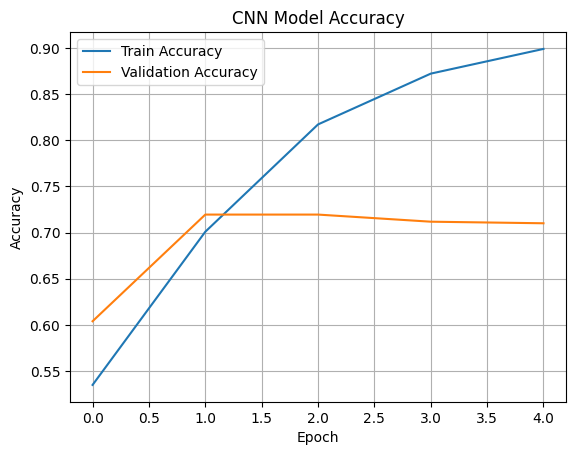

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('CNN Model Accuracy')
plt.grid(True)
plt.show()



37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
📋 Classification Report (CNN):
              precision    recall  f1-score   support

    negative       0.42      0.37      0.39       175
     neutral       0.75      0.78      0.76       622
    positive       0.77      0.75      0.76       372

    accuracy                           0.71      1169
   macro avg       0.65      0.63      0.64      1169
weighted avg       0.70      0.71      0.71      1169



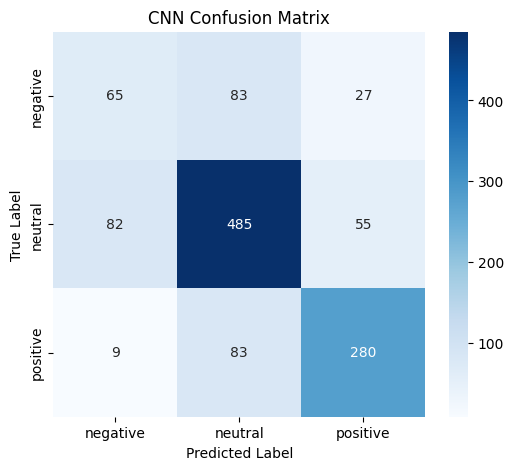

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict using the trained CNN model
y_pred_cnn = model.predict(X_valid)
y_pred_labels = y_pred_cnn.argmax(axis=1)  # Convert probabilities to class index

# Print classification report
print("📋 Classification Report (CNN):")
print(classification_report(y_valid, y_pred_labels, target_names=label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_valid, y_pred_labels)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CNN Confusion Matrix')
plt.show()




In [19]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, GRU, Dense, Dropout

# Constants
VOCAB_SIZE = len(tokenizer.word_index) + 1
EMBEDDING_DIM = 64
MAX_LEN = X.shape[1]
NUM_CLASSES = len(label_encoder.classes_)

# Build GRU model
def build_gru_model():
    input_layer = Input(shape=(MAX_LEN,))
    
    # Word embedding layer
    embedding = Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM)(input_layer)

    # GRU layer (processes sequence of words)
    gru = GRU(64, return_sequences=False)(embedding)

    # Optional dense + dropout
    dense = Dense(64, activation='relu')(gru)
    dropout = Dropout(0.5)(dense)

    # Output layer
    output = Dense(NUM_CLASSES, activation='softmax')(dropout)

    model = Model(inputs=input_layer, outputs=output)
    return model


In [20]:
model_gru = build_gru_model()

model_gru.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

model_gru.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 50, 64)         │       670,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 699,971 (2.67 MB)

 Trainable params: 699,971 (2.67 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history_gru = model_gru.fit(X_train, y_train,
                            validation_data=(X_valid, y_valid),
                            epochs=5,
                            batch_size=32)




Epoch 1/5
147/147 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.5144 - loss: 1.0054 - val_accuracy: 0.5321 - val_loss: 0.9844
Epoch 2/5
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.5363 - loss: 0.9904 - val_accuracy: 0.5321 - val_loss: 0.9845
Epoch 3/5
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.5518 - loss: 0.9767 - val_accuracy: 0.5321 - val_loss: 0.9862
Epoch 4/5
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.5366 - loss: 0.9866 - val_accuracy: 0.5321 - val_loss: 0.9844
Epoch 5/5
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.5330 - loss: 0.9869 - val_accuracy: 0.5321 - val_loss: 0.9853


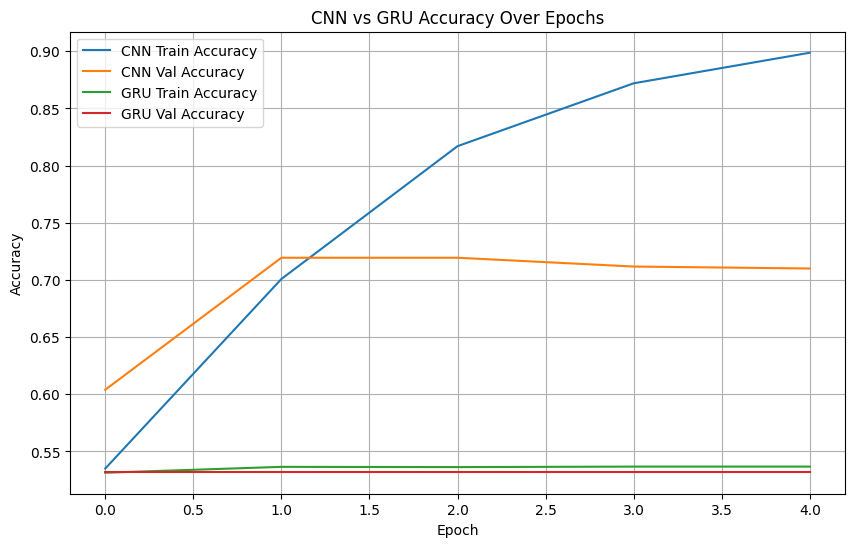

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='CNN Train Accuracy')
plt.plot(history.history['val_accuracy'], label='CNN Val Accuracy')
plt.plot(history_gru.history['accuracy'], label='GRU Train Accuracy')
plt.plot(history_gru.history['val_accuracy'], label='GRU Val Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN vs GRU Accuracy Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

